# Private working draft

Historical coursework outputs are retained and have not been regenerated. See README.md and REVIEW_NOTES.md before rerunning or quoting results. The local data path is configurable through NEUTRINO_DATA_DIR.

# Neutrino event classification

This mini-project's dataset is comprised of a number of small files containing images of simulated neutrino interactions in a hypothetical detector that looks an awful lot like the detectors of the NOvA experiment. For each neutrino interaction the images consist of two $100 \times 80$ pixel images that represent the $x \times z$ and $y \times z$ projections of the tracks of particles in the detector.

The data for this mini-project comes in the form of the following files:

| File | Description |
| ----------- | ----------- |
| neutrino1.h5 | The 1st HDF5 file containing event images and meta deta |
| $\vdots$ | The middle ones |
| neutrino200.h5| The 200th HDF5 file|


The images show the energy deposited by simulated neutrinos in a NOvA like detector. Some of the meta information in the hdf5 file is described below

| Label | Description |
| ----------- | ----------- |
| neutrino/nuenergy | Neutrino Energy (GeV) |
| neutrino/lepenergy | Lepton Energy (GeV) |
| neutrino/interaction | Interaction |
| neutrino/finalstate | Final State |
 

The [PDG code](https://pdg.lbl.gov/2019/reviews/rpp2019-rev-monte-carlo-numbering.pdf) is a number which identifies the particle type (e.g electron=11, electron-neutrino=12, etc.)

The $interaction$ says what kind of interaction occured and is defined in the enumeration below.

## Machine learning tasks
1. Develop a machine learning classifier that can successfully identify $\nu_\mu$ charged-current events
2. Test your machine learning classifier and investigate how the efficiency of the classifier depends on the meta data variables shown above

### Potential extensions
1. Write a machine learning algorithm to determine the energy of the neutrino
2. Write a machine learning algorithm to determine the flavour of the neutrino
3. Write a machine learning algorithm to determine $y=$ lepton energy over neutrino energy
4. Write a machine learning algorithm to determine the number of protons or pions
5. Write a machine learning algorithm to determine the interaction mode.




In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt 
SEED = 42

import os, random
import tensorflow as tf
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [2]:
import enum 
class Interaction(enum.Enum):
    kNumuQE =0           # Numu CC QE interaction
    kNumuRes =1           # Numu CC Resonant interaction
    kNumuDIS = 2          # Numu CC DIS interaction
    kNumuOther = 3        # Numu CC, other than above
    kNueQE = 4            # Nue CC QE interaction
    kNueRes = 5           # Nue CC Resonant interaction
    kNueDIS = 6           # Nue CC DIS interaction
    kNueOther = 7         # Nue CC, other than above
    kNutauQE = 8          # Nutau CC QE interaction
    kNutauRes = 9         # Nutau CC Resonant interaction
    kNutauDIS =10         # Nutau CC DIS interaction
    kNutauOther =11       # Nutau CC, other than above
    kNuElectronElastic = 12# NC Nu On E Scattering
    kNC =13                # NC interaction
    kCosmic =14           # Cosmic ray background
    kOther =15            # Something else.  Tau?  Hopefully we don't use this
    kNIntType=16          # Number of interaction types, used like a vector size

    
class FinalState(enum.Enum):
    kNumu0tr0sh=0          # Numu CC - no track no shower
    kNumu0tr1sh=1          # Numu CC - no track  1 shower
    kNumu0tr2sh=enum.auto()          # Numu CC - no track  2 shower
    kNumu0trMsh=enum.auto()          # Numu CC - no track 3+ shower
    kNumu1tr0sh=enum.auto()          # Numu CC -  1 track no shower
    kNumu1tr1sh=enum.auto()          # Numu CC -  1 track  1 shower
    kNumu1tr2sh=enum.auto()          # Numu CC -  1 track  2 shower
    kNumu1trMsh=enum.auto()          # Numu CC -  1 track 3+ shower
    kNumu2tr0sh=enum.auto()          # Numu CC -  2 track no shower
    kNumu2tr1sh=enum.auto()          # Numu CC -  2 track  1 shower
    kNumu2tr2sh=enum.auto()          # Numu CC -  2 track  2 shower
    kNumu2trMsh=enum.auto()          # Numu CC -  2 track 3+ shower
    kNumuMtr0sh=enum.auto()          # Numu CC - 3+ track no shower
    kNumuMtr1sh=enum.auto()          # Numu CC - 3+ track  1 shower
    kNumuMtr2sh=enum.auto()          # Numu CC - 3+ track  2 shower
    kNumuMtrMsh=enum.auto()          # Numu CC - 3+ track 3+ shower
    kNue0tr0sh=enum.auto()           # Nue CC - no track no shower
    kNue0tr1sh=enum.auto()           # Nue CC - no track  1 shower
    kNue0tr2sh=enum.auto()           # Nue CC - no track  2 shower
    kNue0trMsh=enum.auto()           # Nue CC - no track 3+ shower
    kNue1tr0sh=enum.auto()           # Nue CC -  1 track no shower
    kNue1tr1sh=enum.auto()           # Nue CC -  1 track  1 shower
    kNue1tr2sh=enum.auto()           # Nue CC -  1 track  2 shower
    kNue1trMsh=enum.auto()           # Nue CC -  1 track 3+ shower
    kNue2tr0sh=enum.auto()           # Nue CC -  2 track no shower
    kNue2tr1sh=enum.auto()           # Nue CC -  2 track  1 shower
    kNue2tr2sh=enum.auto()           # Nue CC -  2 track  2 shower
    kNue2trMsh=enum.auto()           # Nue CC -  2 track 3+ shower
    kNueMtr0sh=enum.auto()           # Nue CC - 3+ track no shower
    kNueMtr1sh=enum.auto()           # Nue CC - 3+ track  1 shower
    kNueMtr2sh=enum.auto()           # Nue CC - 3+ track  2 shower
    kNueMtrMsh=enum.auto()           # Nue CC - 3+ track 3+ shower
    kNC0tr0sh=enum.auto()           # NC CC - no track no shower
    kNC0tr1sh=enum.auto()           # NC CC - no track  1 shower
    kNC0tr2sh=enum.auto()           # NC CC - no track  2 shower
    kNC0trMsh=enum.auto()           # NC CC - no track 3+ shower
    kNC1tr0sh=enum.auto()           # NC CC -  1 track no shower
    kNC1tr1sh=enum.auto()           # NC CC -  1 track  1 shower
    kNC1tr2sh=enum.auto()           # NC CC -  1 track  2 shower
    kNC1trMsh=enum.auto()           # NC CC -  1 track 3+ shower
    kNC2tr0sh=enum.auto()           # NC CC -  2 track no shower
    kNC2tr1sh=enum.auto()           # NC CC -  2 track  1 shower
    kNC2tr2sh=enum.auto()           # NC CC -  2 track  2 shower
    kNC2trMsh=enum.auto()           # NC CC -  2 track 3+ shower
    kNCMtr0sh=enum.auto()           # NC CC - 3+ track no shower
    kNCMtr1sh=enum.auto()           # NC CC - 3+ track  1 shower
    kNCMtr2sh=enum.auto()           # NC CC - 3+ track  2 shower
    kNCMtrMsh=enum.auto()           # NC CC - 3+ track 3+ shower
    kCosmicFS=enum.auto()           # Cosmic ray background
    kOtherFS=enum.auto()            # Something else.  Tau?  Hopefully we don't use this
    kNFStType=enum.auto()            # Number of interaction types, used like a vector size


In [3]:
from pathlib import Path
import os

data_dir = Path(os.environ.get("NEUTRINO_DATA_DIR", "data"))
file_path = data_dir / "neutrino1.h5"

df = h5py.File(file_path, "r")


In [4]:
#Print the keys in the neutrino meta data
print(df.keys())
print(df["neutrino"].keys())

#Get an numpy array containing the event image, and reshape it from flat to 2x100x80
print(df["cvnmap"].shape)
print(df['neutrino']['evt'])
event0=np.array(df['cvnmap'][3]).reshape((2,100,80))

<KeysViewHDF5 ['cvnmap', 'neutrino']>
<KeysViewHDF5 ['cycle', 'evt', 'finalstate', 'finalstateprong', 'interaction', 'lepenergy', 'nuenergy', 'parent', 'particles', 'rec.training.trainingdata_idx', 'run', 'subevt', 'subrun', 'vtxx', 'vtxy', 'vtxz']>
(7001, 16000)
<HDF5 dataset "evt": shape (7001, 1), type "<u4">


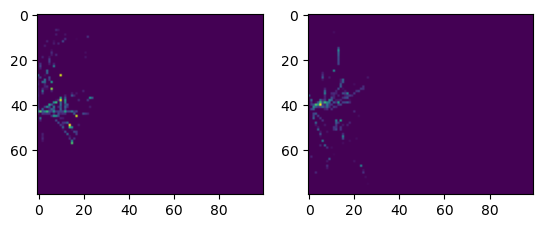

In [5]:
#Plot the first event, look it is a nice long muon track
fig, ax = plt.subplots(1,2)
ax[0].imshow(event0[1].T)
ax[1].imshow(event0[0].T)

In [6]:
interaction = df["neutrino"]["interaction"][3]
nu_energy = df["neutrino"]["nuenergy"][3]
lep_energy = df["neutrino"]["lepenergy"][3]
final_state = df["neutrino"]["finalstate"][3]

print("interaction =", interaction)
print("neutrino energy =", nu_energy, "GeV")
print("lepton energy =", lep_energy)
print("final state =", final_state)

interaction = [13]
neutrino energy = [13.677229] GeV
lepton energy = [2.7689836]
final state = [46]


(array([3358., 1891., 1013.,  394.,  184.,   85.,   44.,   14.,    8.,
          10.]),
 array([ 0.        ,  8.22953796, 16.45907593, 24.68861389, 32.91815186,
        41.14768982, 49.37722778, 57.60676575, 65.83630371, 74.06584167,
        82.29537964]),
 <BarContainer object of 10 artists>)

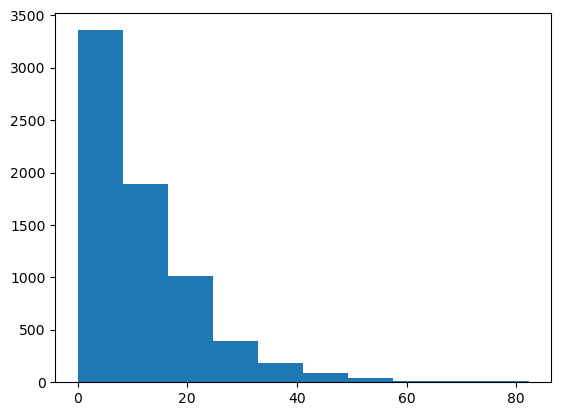

In [7]:
fs=np.array(df['neutrino']['finalstate'])
nuenergy=np.array(df['neutrino']['nuenergy'])
fig, ax = plt.subplots()
ax.hist(nuenergy)

In [8]:
file_list = sorted(data_dir.glob("*.h5"))[:3]  # Load a list of 3 files instead of one single file

X_list = []
nu_energy_list = []
lep_energy_list = []
interaction_list = []
final_state_list = []

for file_path in file_list:
    with h5py.File(file_path, "r") as f:
        X_file = np.array(f["cvnmap"]).reshape((-1, 2, 100, 80))
        
        nu_energy_file = np.array(f["neutrino"]["nuenergy"]).flatten()
        lep_energy_file = np.array(f["neutrino"]["lepenergy"]).flatten()
        interaction_file = np.array(f["neutrino"]["interaction"]).flatten()
        final_state_file = np.array(f["neutrino"]["finalstate"]).flatten()

        X_list.append(X_file)
        nu_energy_list.append(nu_energy_file)
        lep_energy_list.append(lep_energy_file)
        interaction_list.append(interaction_file)
        final_state_list.append(final_state_file)

X = np.concatenate(X_list, axis=0)
nu_energy = np.concatenate(nu_energy_list, axis=0)
lep_energy = np.concatenate(lep_energy_list, axis=0)
interaction = np.concatenate(interaction_list, axis=0)
final_state = np.concatenate(final_state_list, axis=0)

## Task 1: Build a classifer that can successfully identify $\nu_\mu$ charged-current events

### Binary classifier
We want to train a machine learning classifier to identify a specific type of neutrino interaction. First we need to build a binary classifier that works like this:

$$\text{Input: detector images} \rightarrow \text{Output: }\begin{cases}1 & \nu_\mu \text{ charged-current event} \\0 & \text{not this event}\end{cases}$$

where charged-current events are labelled $0, 1, 2, 3$.

In [9]:
# Binary classifier - only returns True if label is 0,1,2,3 (NuMu CC events)
y = np.isin(interaction, [0,1,2,3]).astype(np.float32)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("signal fraction:", y.mean())

X shape: (21016, 2, 100, 80)
y shape: (21016,)
signal fraction: 0.88208985


In [10]:
from sklearn.model_selection import train_test_split

# Put images into a CNN-friendly shape, i.e.(N, height, width, channels)
X = np.transpose(X,(0,2,3,1)).astype(np.float32)
X_norm = X / np.max(X)   # Normalise the inputs

# First split of all metadata: Train (70%) and Temp (30%)
(X_train, X_temp, 
 y_train, y_temp, 
 nu_train, nu_temp, 
 lep_train, lep_temp, 
 int_train, int_temp, 
 fs_train, fs_temp) = train_test_split(X_norm, y, nu_energy, lep_energy, interaction, final_state, 
                                       test_size=0.30, random_state=42, stratify=y)

# Second split from Temp: Validation (15%) and Test (15%)
(X_val, X_test, 
 y_val, y_test, 
 nu_val, nu_test, 
 lep_val, lep_test, 
 int_val, int_test, 
 fs_val, fs_test) = train_test_split(X_temp, y_temp, nu_temp, lep_temp, int_temp, fs_temp, 
                                     test_size=0.50, random_state=42, stratify=y_temp)

print("Test set metadata:")
print(f"Images: {X_test.shape[0]}, Nu Energy: {nu_test.shape[0]}, Interaction: {int_test.shape[0]}")

Test set metadata:
Images: 3153, Nu Energy: 3153, Interaction: 3153


### Build a CNN model
Our goal is to learn **spatial patterns** in the detector images that distinguish νμ charged-current events from other events. **CNN (Convolutional Neural Network)** is appropriate because they detect spatial features, exploit local correlations in images and require far fewer parameters than fully connected networks

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(100,80,2)),
    layers.Conv2D(16,3,activation="relu",padding="same"),   # learns 16 filters, each with size 3x3 sliding across whole image
    layers.MaxPooling2D((2,2)), # 2×2 pooling window moves across the image keeping only the maximum value
    layers.Conv2D(32,3,activation="relu",padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,3,activation="relu",padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),   # A fully connected layer that combines all extracted features
    layers.Dropout(0.3),   # randomly sets 30% of neurons to zero to prevent overfitting
    layers.Dense(1,activation="sigmoid")])   # gives a probability between 0 and 1

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# Introduce early stopping when validation stops improving
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val,y_val), epochs=10, batch_size=32, callbacks=[early_stop])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 80, 16)    │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 40, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       491,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,089 (1.96 MB)

 Trainable params: 515,089 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8819 - loss: 0.3389 - val_accuracy: 0.8810 - val_loss: 0.3244
Epoch 2/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8821 - loss: 0.2835 - val_accuracy: 0.8823 - val_loss: 0.2962
Epoch 3/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.8822 - loss: 0.2648 - val_accuracy: 0.8810 - val_loss: 0.2783
Epoch 4/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.8826 - loss: 0.2506 - val_accuracy: 0.8791 - val_loss: 0.2706
Epoch 5/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.8820 - loss: 0.2417 - val_accuracy: 0.8782 - val_loss: 0.2668
Epoch 6/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8839 - loss: 0.2319 - val_accuracy: 0.8766 - val_loss: 0.2645
Epoch 7/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8880 - loss: 0.2202 - val_accuracy: 0.8715 - val_loss: 0.2691
Epoch 8/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8952 - loss: 0.2089 - 

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8804 - loss: 0.2500
Test loss: 0.24999041855335236
Test accuracy: 0.8804313540458679


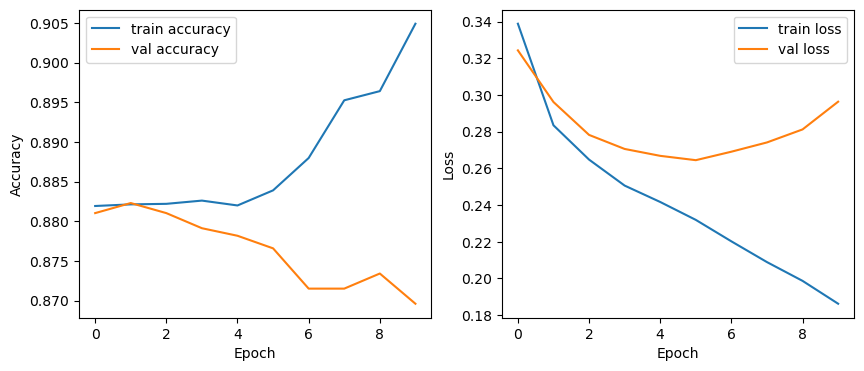

In [13]:
# Plot the accuracies and losses
fig,ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(history.history["accuracy"], label="train accuracy")
ax[0].plot(history.history["val_accuracy"], label="val accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(history.history["loss"], label="train loss")
ax[1].plot(history.history["val_loss"], label="val loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred = (model.predict(X_test)>0.5).astype(int)

# Print a detailed report
print(classification_report(y_test, y_pred))

# Look at the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
              precision    recall  f1-score   support

         0.0       0.46      0.08      0.14       372
         1.0       0.89      0.99      0.94      2781

    accuracy                           0.88      3153
   macro avg       0.68      0.54      0.54      3153
weighted avg       0.84      0.88      0.84      3153

Confusion Matrix:
[[  31  341]
 [  36 2745]]


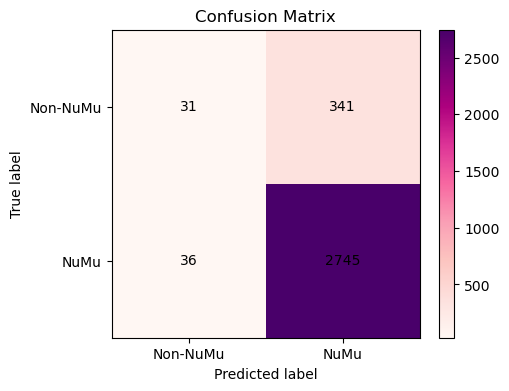

In [15]:
cm = confusion_matrix(y_test, y_pred)
# Make a coloured plot of the confusion matrix for better visualisation
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="RdPu")
plt.colorbar()
labels = ["Non-NuMu", "NuMu"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

# annotate numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

#### Key Observations:
1. Model is heavily biased towards $\nu_\mu$ and predicts $\nu_\mu$ almost all the time. Since most events are $\nu_\mu$ events the model gets high accuracy.
2. Model performs very poorly on Non-$\nu_\mu$ events, out of all events it only correctly finds $\approx 10$%.

#### Improvement:
Try to fix the strong class imbalance by introducing **class weights**.

In [16]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print(class_weights)

{0: 4.239481268011527, 1: 0.5668541923551171}


In [17]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=20, batch_size=32, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.7877 - loss: 0.4088 - val_accuracy: 0.7395 - val_loss: 0.4749
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.8019 - loss: 0.3516 - val_accuracy: 0.7640 - val_loss: 0.4394
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8089 - loss: 0.3338 - val_accuracy: 0.7716 - val_loss: 0.4398
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.8263 - loss: 0.3038 - val_accuracy: 0.7906 - val_loss: 0.4271
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.8370 - loss: 0.2883 - val_accuracy: 0.7871 - val_loss: 0.4445


In [18]:
# Get predictions
y_pred = (model.predict(X_test)>0.5).astype(int)

# Print a detailed report
print(classification_report(y_test, y_pred))

# Look at the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
              precision    recall  f1-score   support

         0.0       0.31      0.91      0.46       372
         1.0       0.98      0.72      0.83      2781

    accuracy                           0.75      3153
   macro avg       0.65      0.82      0.65      3153
weighted avg       0.90      0.75      0.79      3153

Confusion Matrix:
[[ 339   33]
 [ 768 2013]]


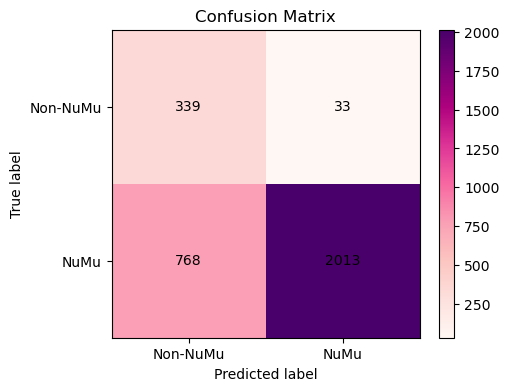

In [19]:
# Make a coloured plot of the confusion matrix for better visualisation
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="RdPu")
plt.colorbar()
labels = ["Non-NuMu", "NuMu"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

# annotate numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

Although overall accuracy decreased slightly, the weighted model achieved a much more balanced performance, with non-$\nu_\mu$ recall increasing to $\approx 90$%. It provides a more meaningful classification compared to the non-weighted model by significantly improving detection of the minority class.

## Task 2: Test the classifier and investigate the efficiency
First, we need to **generate model predictions** by running it on a test dataset. 

In [20]:
# Get raw probabilities from the model 
probs = model.predict(X_test).flatten()

# Turn them into binary decisions: return 1 if prob > 0.5, else 0
y_pred = (probs>0.5).astype(int)

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


We can evaluate the performace by plotting the **ROC** (Receiver Operating Characteristic).
It visualises the binary classifier's performance by **plotting the True Positive Rate (TPR) against 
False Positive Rate (FPR)** across all classification thresholds.

- x-axis: False Positive Rate
$$\text{FPR}=\frac{\text{background wrongly predicted as signal}}{\text{all background}}$$
- y-axis: True Positive Rate
$$\text{FPR}=\frac{\text{signal corrected predicted}}{\text{all signal}}$$

AUC is the Area Under the Curve,
- AUC = 1: perfect classifier
- AUC = 0.5: Random guessing
- AUC < 0.5: worse than random 

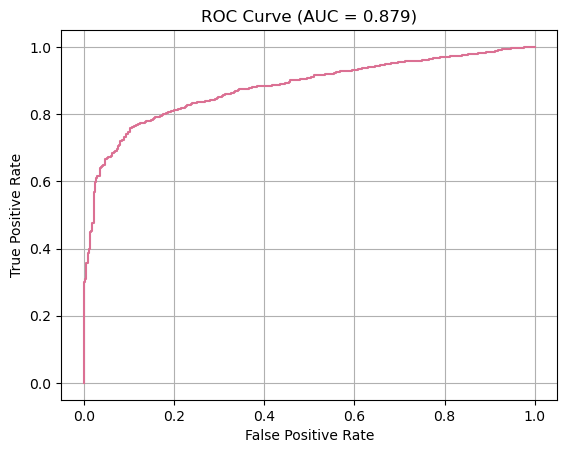

In [27]:
from sklearn.metrics import roc_curve, auc
# Plot a ROC curve to visualise false positives vs false negatives
fpr,tpr,_ = roc_curve(y_test,probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='palevioletred')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.grid()
plt.show()

The ROC curve shows that the classifier has strong performance, being able to capture most signal while rejecting most background. It also illustrates the trade-off between signal efficiency and background rejection across different classification thresholds. The steep rise of the curve at low false positive rates shows that the classifier can retain a high fraction of signal events while rejecting most background.

Next, we **plot Efficiency vs. metadata variables** (neutrino energy, lepton energy, interaction tyhpe and final state)

#### 1. Efficiency vs. Neutrino Energy and Lepton Energy
Efficiency is defined as:
$$ \text{Efficiency} = \frac {\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$
Model performance may not be uniform over all energies. Since energy values are continuous, we **bin the energy values** and calculate the efficiency for each bin. This helps us see if the model struggles with low-energy neutrinos which produce smaller tracks that are harder to see.

In [21]:
def plot_efficiency_binned(energies, true_labels, pred_labels, var_name="Energy (GeV)", n_bins=10):
    """
    This function calculates and plots efficiency vs a continuous variable e.g. energy 
    
    Inputs:
    energies: NumPy array of energy values.
    true_labels: NumPy array of true labels (0 or 1).
    pred_labels: NumPy array of model predictions (0 or 1).
    """
    # Filter for signal events (where true_label == 1)
    mask = (true_labels==1)   # Boolean mask that returns array of True and False
    signal_energies = energies[mask]
    signal_preds = pred_labels[mask]

    # Define the bins
    bins = np.linspace(np.min(signal_energies), np.max(signal_energies), n_bins+1)
    bin_centers = (bins[:-1]+bins[1:]) / 2
    
    # Assign each event to a bin index (indices[i] tells which bin the i-th event belongs to)
    indices = np.digitize(signal_energies,bins)

    # Lists for bin efficiencies
    bin_efficiencies = []
    bin_errors = []  # Add error bars to bins of efficiencies

    for i in range(1,len(bins)):
        # Select predictions that fall in this specific bin
        preds_in_bin = signal_preds[indices==i]
        
        if len(preds_in_bin) > 0:
            eff = np.mean(preds_in_bin)
            # Statistical error (Binomial)
            err = np.sqrt(eff *(1-eff) / len(preds_in_bin))
        else:
            eff = 0
            err = 0     
        bin_efficiencies.append(eff)
        bin_errors.append(err)

    # Plotting
    plt.errorbar(bin_centers, bin_efficiencies, yerr=bin_errors, fmt='o-', color='palevioletred', capsize=3)
    plt.xlabel(var_name)
    plt.ylabel('Efficiency')
    plt.title(f'Efficiency vs {var_name}')
    plt.grid(True, alpha=0.3)
    plt.show()

The uncertainty in efficiency is calculated using **binomial statistics**:
$$\epsilon = \sqrt{\frac{\epsilon (1-\epsilon)}{N}}$$
where $\epsilon$ is the efficiency and $N$ is the number of events in that bin.

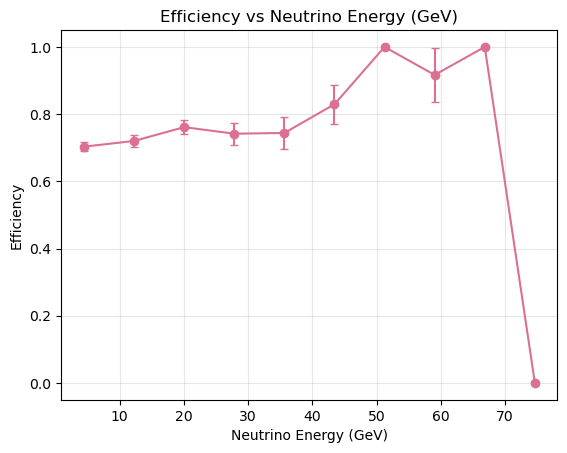

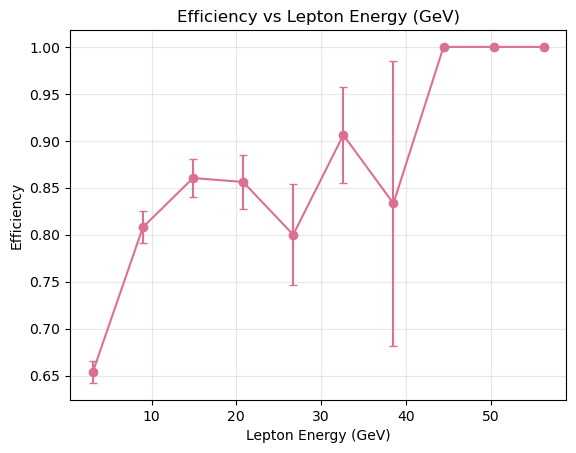

In [22]:
# 1. Neutrino Energy
plot_efficiency_binned(nu_test, y_test, y_pred, "Neutrino Energy (GeV)")

# 2. Lepton Energy
plot_efficiency_binned(lep_test, y_test, y_pred, "Lepton Energy (GeV)")

A general trend of **better performance at higher energies** can be observed. This is because at higher energies, muon tracks are clearer and easier to identify.

We also want to analyse how often background is incorrectly classified as a signal, i.e. the false positives.

In [23]:
def plot_background_binned(energies, true_labels, pred_labels, var_name="Energy (GeV)", n_bins=10):
    """
    This function calculates and plots the background efficiency (false positive rate) vs energy
    Inputs:
    energies: NumPy array of energy values.
    true_labels: NumPy array of true labels (0 or 1).
    pred_labels: NumPy array of model predictions (0 or 1).
    """
    # Background events
    mask = (true_labels == 0)
    bg_energies = energies[mask]
    bg_preds = pred_labels[mask]
    # Define bins
    bins = np.linspace(np.min(bg_energies), np.max(bg_energies), n_bins+1)
    bin_centers = (bins[:-1]+bins[1:])/2
    indices = np.digitize(bg_energies,bins)

    rates = []
    errors = []  # Error bars
    for i in range(1, len(bins)):
        preds_in_bin = bg_preds[indices == i]
        if len(preds_in_bin) > 0:
            rate = np.mean(preds_in_bin)  # fraction predicted as signal
            err = np.sqrt(rate * (1 - rate) / len(preds_in_bin))
        else:
            rate = 0
            err = 0
        rates.append(rate)
        errors.append(err)

    plt.errorbar(bin_centers,rates,yerr=errors,fmt='o-',capsize=3,color='palevioletred')
    plt.xlabel(var_name)
    plt.ylabel('Background Acceptance')
    plt.title(f'Background Acceptance vs {var_name}')
    plt.grid(True, alpha=0.3)
    plt.show()

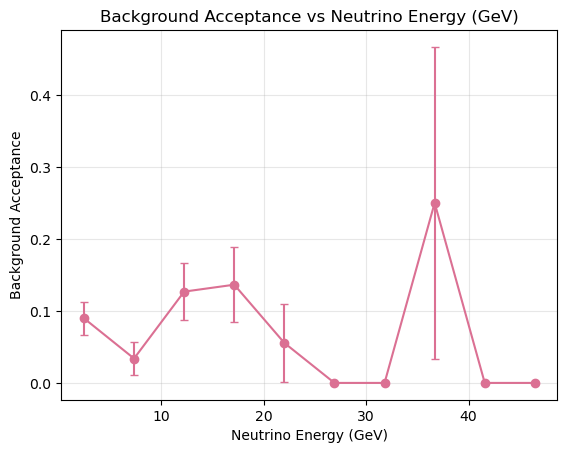

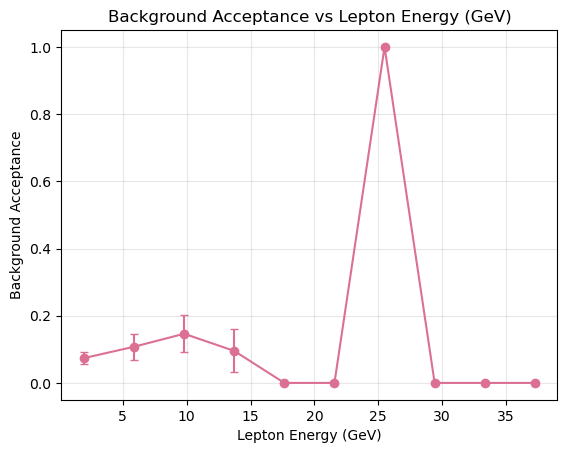

In [24]:
plot_background_binned(nu_test, y_test, y_pred, "Neutrino Energy (GeV)")
plot_background_binned(lep_test, y_test, y_pred, "Lepton Energy (GeV)")

We can observe a general trend of lower background acceptance at high energies.
The classifier performance depends strongly on neutrino and lepton energy, as higher-energy muons produce longer and more easily identifiable tracks. This leads to improved background rejection at higher energies.

#### 2. Efficiency vs. Interaction and Final State
Since interaction type and final states are **discrete data** (for example, interaction codes 0, 1, 2, 3 are discrete), we can loop through the unique values found in the array.

In [25]:
def plot_efficiency_categorical(categories, true_labels, pred_labels, mapping, title):
    """
    This function calculates efficiencies (both signal and background) for discrete categories (Interaction/Final State).
    """
    # Filter for signal events (nu_mu CC)
    signal_mask = (true_labels==1)
    # Filter for background events (non-nu_mu CC)
    background_mask = (true_labels==0)
    unique_ids = np.unique(categories)

    names = []
    eff_signal = []
    eff_background = []

    for cat_id in unique_ids:
        name = mapping.get(cat_id, f"ID{cat_id}")
        # Signal efficiency
        sig = pred_labels[(categories == cat_id) & signal_mask]
        if len(sig) > 0:
            eff_s = np.mean(sig)
        else:
            eff_s = 0
        # Background acceptance
        bg = pred_labels[(categories == cat_id) & background_mask]
        if len(bg) > 0:
            eff_b = np.mean(bg)
        else:
            eff_b = 0
        names.append(name)
        eff_signal.append(eff_s)
        eff_background.append(eff_b)
        
    x = np.arange(len(names))

    plt.figure(figsize=(10,5))
    plt.bar(x-0.2, eff_signal, width=0.4, color='palevioletred', label="Signal Eff")
    plt.bar(x+0.2, eff_background, width=0.4, color='teal', label="Background Acc")
    plt.xticks(x, names, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.ylabel("Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

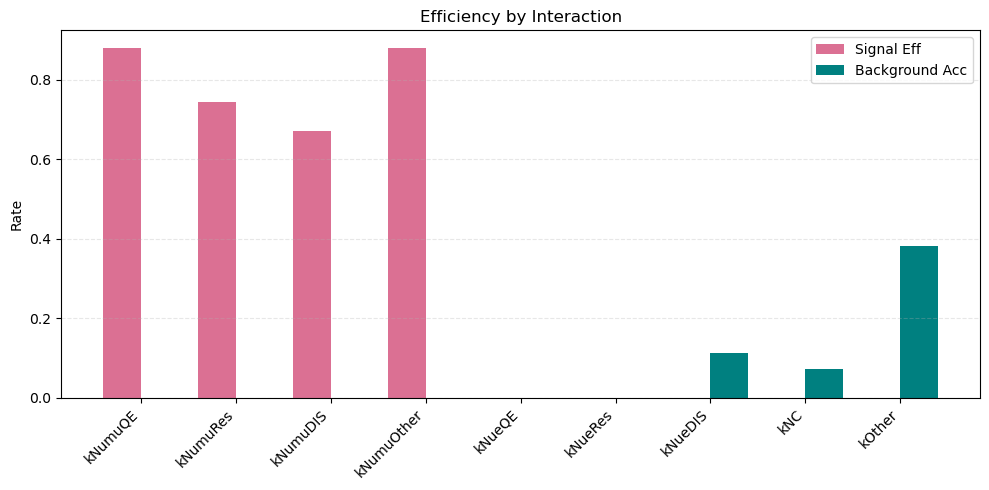

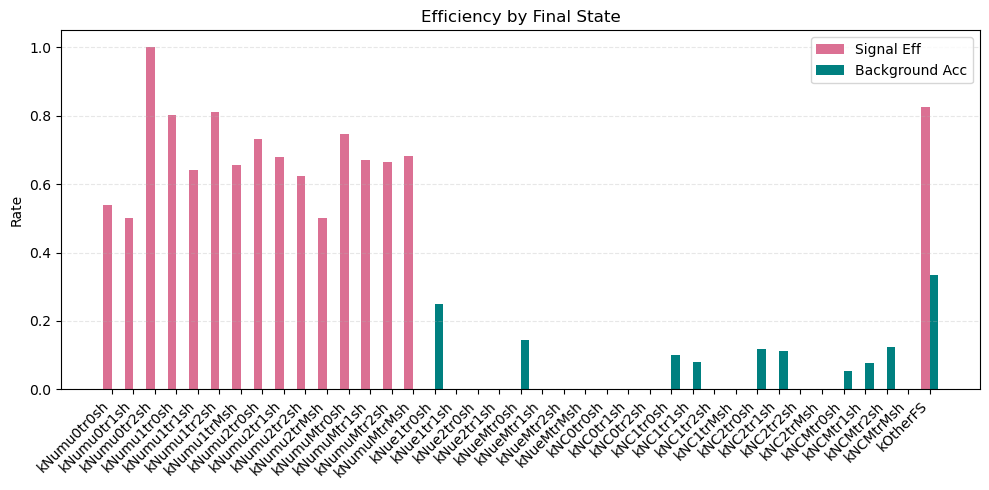

In [26]:
# Define the mappings of categoric metadata from Enums
# m.value is the integer (0, 1, 2...) for Interaction
# m.name is the string ('kNumuQE', 'kNumu1trMsh'...) for Final State
int_map = {m.value: m.name for m in Interaction}   # Mapping for Interactions
fs_map = {m.value: m.name for m in FinalState}     # Mapping for Final States

# 3. Interaction Type
plot_efficiency_categorical(int_test, y_test, y_pred, int_map, "Efficiency by Interaction")

# 4. Final State
plot_efficiency_categorical(fs_test, y_test, y_pred, fs_map, "Efficiency by Final State")

#### Interaction:

The classifier performs best on quasi-elastic (QE) interactions, which produce simple and clean event topologies. Performance decreases for DIS events due to their complex and multi-particle final states. Background contamination is higher for neutral-current interactions, where no clear muon track is present.
#### Final state:
The classifier performance varies significantly across final states, reflecting differences in event topology. Final states with clear muon tracks are classified with high efficiency, while more complex or ambiguous topologies lead to reduced performance. Background contamination is highest for final states lacking a clear muon track.

## Optional task 1: Determine the energy of the neutrino (Regression)
In this task we are focusing on **$\nu_\mu$ CC events only**. This is because muons leave a clear, long track, and there is strong correlation between image and energy. This ensures a consistent mapping between detector images and neutrino energy. On the other hand, including other interaction types, such as neutral-current events where the outgoing neutrino is not detected, would introduce ambiguity and degrade model performance.

We can first plot a histogram to show the energy distribution.

In [28]:
# Filter for only nu_mu CC events
mask_signal = (y==1)
X_signal = X_norm[mask_signal]  # Divide by global max for training and testing
nu_energy_signal = nu_energy[mask_signal]

# Split into training and testing
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X_signal,nu_energy_signal,test_size=0.2,random_state=42)

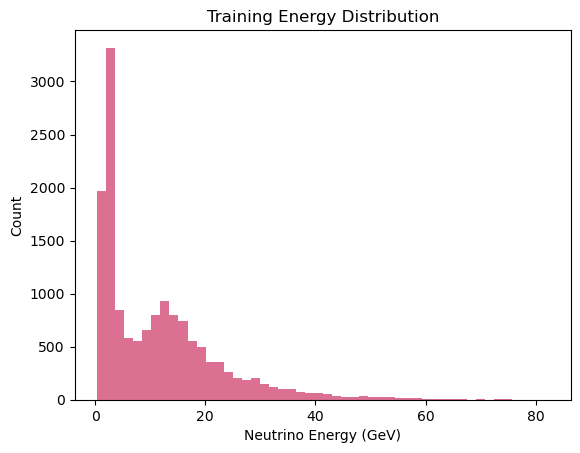

In [29]:
plt.hist(y_train_en,bins=50,color='palevioletred')
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Count")
plt.title("Training Energy Distribution")
plt.show()

The energy distribution is very strongly skewed - **huge concentration at low energies and long sparse tail to high energies**.

The model will be trained mostly on low-energy events and sees relatively few high-energy examples.
It might tend to underpredict high-energy events and compress predictions toward the middle because it's a 'safer' guess.

To avoid this, we can try **training the model on the log values of energy**.

In [30]:
# Train on the log of the energy values to account for the long-tailed energy values
y_train_en_log = np.log1p(y_train_en)

In [31]:
energy_model = keras.Sequential([
    # Use the same convolutional layers for classification
    layers.Input(shape=(100,80,2)),
    layers.Conv2D(16, (3,3), activation='relu',padding="same"),  
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu',padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Random dropouts prevents memorizing specific events
    layers.Dense(64, activation='relu'),
    # Output 1 neuron with linear activation which allows the model to predict any energy value
    layers.Dense(1, activation='linear')])

energy_model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
energy_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 80, 16)    │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 40, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,929 (3.87 MB)

 Trainable params: 1,014,929 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Train the model on log energy values
history_en = energy_model.fit(X_train_en,y_train_en_log,epochs=20,
                              validation_split=0.2,batch_size=32,callbacks=[early_stop])

# Get predictions
y_pred_en_log = energy_model.predict(X_test_en).flatten()
y_pred_en = np.expm1(y_pred_en_log)  # Convert predictions back from log values

Epoch 1/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 0.3308 - mae: 0.7052 - val_loss: 0.2970 - val_mae: 0.6541
Epoch 2/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - loss: 0.2696 - mae: 0.6226 - val_loss: 0.3174 - val_mae: 0.6585
Epoch 3/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - loss: 0.2557 - mae: 0.5993 - val_loss: 0.2993 - val_mae: 0.6401
Epoch 4/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 0.2440 - mae: 0.5818 - val_loss: 0.2857 - val_mae: 0.6219
Epoch 5/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 0.2347 - mae: 0.5683 - val_loss: 0.2485 - val_mae: 0.5855
Epoch 6/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - loss: 0.2245 - mae: 0.5525 - val_loss: 0.2408 - val_mae: 0.5736
Epoch 7/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - loss: 0.2168 - mae: 0.5415 - val_loss: 0.2315 - val_mae: 0.5592
Epoch 8/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.2080 - mae: 0.5274 - val_loss: 0.2355 - val_mae: 0.5599
Epoch 9/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 

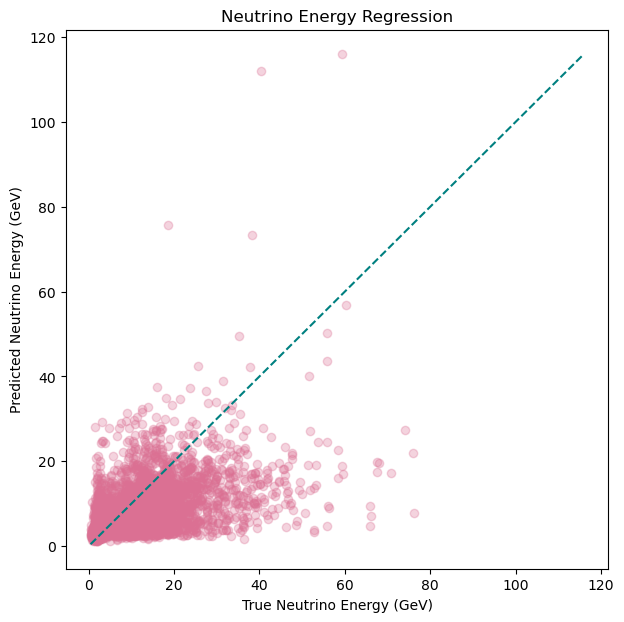

In [33]:
# Plotting the performance
plt.figure(figsize=(7,7))
plt.scatter(y_test_en, y_pred_en, alpha=0.3, color='palevioletred')
emin = min(y_test_en.min(), y_pred_en.min())
emax = max(y_test_en.max(), y_pred_en.max())
plt.plot([emin,emax], [emin,emax], color='teal', linestyle='--') # prediction line
plt.xlabel('True Neutrino Energy (GeV)')
plt.ylabel('Predicted Neutrino Energy (GeV)')
plt.title('Neutrino Energy Regression')
plt.show()

To assess the performance of the energy regression model, we can use three standard metrics: Mean Absolute Error $(\text{MAE})$, Root Mean Squared Error $(\text{RMSE})$, and the coefficient of determination $(\text{R}^2)$.

- $\text{MAE}$ measures the average absolute difference between predicted and true neutrino energies.

- $\text{RMSE}$ measures the square root of the average squared errors. This is useful for identifying whether the model makes significant errors, particularly in the high-energy tail.

- $\text{R}^2$ quantifies how well the model explains the variance in the data relative to a simple baseline predictor (the mean). An $\text{R}^2$ value close to 1 indicates strong predictive performance, while values near or below 0 indicate limited or poor predictive power.

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test_en, y_pred_en))
print("RMSE:", np.sqrt(mean_squared_error(y_test_en, y_pred_en)))
print("R^2:", r2_score(y_test_en, y_pred_en))

MAE: 6.324782371520996
RMSE: 9.955264162537247
R^2: 0.15039312839508057


The $\text{R}^2$ of this model indicates poor performance compared to just predicting the mean. This means the log-transform of energy value is not a good strategy. 

We can try training with raw energy values and weighing high-energy events more to account for the highly skewed energy distribution instead.

In [35]:
# Train the model with raw energy values
weights = nu_energy_signal / np.mean(nu_energy_signal)  # Introducing weights
history_en = energy_model.fit(X_train_en, y_train_en, sample_weight=weights, epochs=20,
                              validation_split=0.2, batch_size=32)

# Get predictions
y_pred_en = energy_model.predict(X_test_en).flatten()

Epoch 1/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 5.7057 - mae: 6.1991 - val_loss: 5.9238 - val_mae: 6.5163
Epoch 2/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 5.0622 - mae: 5.6880 - val_loss: 5.5300 - val_mae: 6.1070
Epoch 3/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 4.6320 - mae: 5.4224 - val_loss: 5.5800 - val_mae: 6.1295
Epoch 4/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 4.4681 - mae: 5.3354 - val_loss: 6.2214 - val_mae: 6.8064
Epoch 5/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 4.1877 - mae: 5.1255 - val_loss: 5.7923 - val_mae: 6.3470
Epoch 6/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - loss: 3.9303 - mae: 4.9634 - val_loss: 5.9163 - val_mae: 6.4303
Epoch 7/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - loss: 3.7847 - mae: 4.8318 - val_loss: 5.7207 - val_mae: 6.2181
Epoch 8/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - loss: 3.5786 - mae: 4.7016 - val_loss: 6.0725 - val_mae: 6.6245
Epoch 9/20
371/371 ━━━━━━━━━━━━━━━━━━━━ 

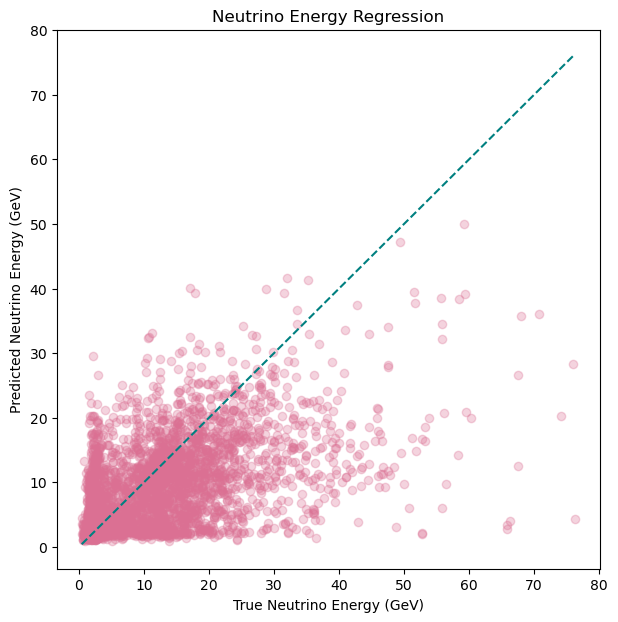

In [36]:
# Plotting the performance
plt.figure(figsize=(7,7))
plt.scatter(y_test_en, y_pred_en, alpha=0.3, color='palevioletred')
emin = min(y_test_en.min(), y_pred_en.min())
emax = max(y_test_en.max(), y_pred_en.max())
plt.plot([emin,emax], [emin,emax], color='teal', linestyle='--') # prediction line
plt.xlabel('True Neutrino Energy (GeV)')
plt.ylabel('Predicted Neutrino Energy (GeV)')
plt.title('Neutrino Energy Regression')
plt.show()

In [37]:
print("MAE:", mean_absolute_error(y_test_en, y_pred_en))
print("RMSE:", np.sqrt(mean_squared_error(y_test_en, y_pred_en)))
print("R^2:", r2_score(y_test_en, y_pred_en))

MAE: 6.062527179718018
RMSE: 9.509051778955843
R^2: 0.2248479723930359


Both models perform poorly on predicting neutrino energy. This is likely due to the highly skewed data and weak correlation between the image and neutrino energy.

## Optional task 2: Determine the flavor of the neutrino
First of all, we need a category for each flavor. We can group the interaction codes from the Enum classes to define these flavors.

In [38]:
def get_flavor_labels(interaction_array):
    """
    Groups interaction codes into flavor categories:
    0: NuMu (Codes 0-3)
    1: NuE   (Codes 4-7)
    2: NuTau (Codes 8-11)
    -1: ignore all other events (NC, cosmic, etc.)
    """
    labels = np.full_like(interaction_array,-1,dtype=np.int32)
    labels[np.isin(interaction_array,[0,1,2,3])] = 0  # NuMu
    labels[np.isin(interaction_array,[4,5,6,7])] = 1  # NuE
    labels[np.isin(interaction_array,[8,9,10,11])] = 2 # NuTau
    return labels

y_flavor = get_flavor_labels(interaction)
mask = (y_flavor != -1)   # Creates a boolean array that returns True for flavored events and False otherwise
# Only keep the rows where the mask is True
X_flavor = X[mask]
y_flavor = y_flavor[mask]

# Normalise
X_flavor = X_flavor / np.max(X_flavor)

print("X_flavor shape:", X_flavor.shape)
print("y_flavor shape:", y_flavor.shape)

# Check class counts
unique, counts = np.unique(y_flavor, return_counts=True)
print("Class counts:", dict(zip(unique, counts)))  # Combine the labels and counts into a dictionary for easy reading

X_flavor shape: (18776, 100, 80, 2)
y_flavor shape: (18776,)
Class counts: {np.int32(0): np.int64(18538), np.int32(1): np.int64(238)}


**01/04/2026**: From the class counts we can see that **most events are $\nu_\mu$ charged-current events**, very little $\nu_e$ events and no $\nu_\tau$ charged-current events at all. Therefore we are building a binary $\nu_\mu$ vs $\nu_e$ classifier instead of a 3-class model.

**02/04/2026**: I added new codes to load files that contain $\nu_\tau$ charged-current events so I can build a **3-class model** that includes $\nu_\tau$ charged-current events. 

However, after running the codes, it shows that **there are no $\nu_\tau$ events at all** in all 200 of the nova files (shocking). Since a supervised classifier cannot learn a class with no examples, we are restricted to $\nu_\mu$ versus $\nu_e$ classification.

In [39]:
# Codes for picking up tau events and skipping invalid files
# This is because I ran into an error of "object 'neutrino' doesn't exist" when scanning the files
# Meaning one or more files did not contain the group "neutrino"
file_list_all = sorted(data_dir.glob("*.h5"))

selected_files = []
skipped_files = []

for file_path in file_list_all:
    try:
        with h5py.File(file_path, "r") as f:
            # Check that the expected group and dataset exist
            if "neutrino" not in f:
                skipped_files.append((file_path.name, "no 'neutrino' group"))
                continue
            all_interaction = np.array(f["neutrino"]["interaction"]).flatten()

        # Check whether tau events (labelled 8,9,10,11) are present
        if np.any(np.isin(all_interaction, [8,9,10,11])):
            selected_files.append(file_path)
    # List out the invalid files
    except Exception as e:
        skipped_files.append((file_path.name,str(e)))

print("Files containing tau events:")
for f in selected_files:
    print(f.name)
print("Skipped files:")
for name, reason in skipped_files:
    print(name, "->", reason)

Files containing tau events:
Skipped files:
neutrino402.h5 -> no 'neutrino' group


In [40]:
# Just one more sanity check to be 100% sure that there are no nu_tau events
print("Unique interaction codes:",np.unique(all_interaction))

Unique interaction codes: [ 0  1  2  3  4  5  6  7 13 15]


Now we can be sure that out of $\approx 1 \text{million}$ events there are not a single $\nu_\tau$ event. This is because $\nu_\tau$ production is intrinsically rare due to its large mass and fast decay. 

In [41]:
# Train test split using the intial 3 files
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_flavor, y_flavor,
    test_size=0.2, random_state=42, stratify=y_flavor)

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_train_f, y_train_f,
    test_size=0.2, random_state=42, stratify=y_train_f)

print(X_train_f.shape, X_val_f.shape, X_test_f.shape)

(12016, 100, 80, 2) (3004, 100, 80, 2) (3756, 100, 80, 2)


In [77]:
# Compute class  weights so that the model doesn't just predict Numu all the time
classes = np.unique(y_train_f)
class_weights_array = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: 0.5064059339177344, 1: 39.526315789473685}


In [43]:
flavour_model = keras.Sequential([
    layers.Input(shape=(100,80,2)),
    layers.Conv2D(16,3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(32,3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(64,3, activation="relu", padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")])

flavour_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
flavour_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 100, 80, 16)    │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 40, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       491,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,089 (1.96 MB)

 Trainable params: 515,089 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history_f = flavour_model.fit(X_train_f, y_train_f, validation_data=(X_val_f, y_val_f),
    epochs=10, batch_size=32, class_weight=class_weights)

Epoch 1/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8931 - loss: 0.7170 - val_accuracy: 0.9141 - val_loss: 0.4775
Epoch 2/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.8811 - loss: 0.6401 - val_accuracy: 0.8475 - val_loss: 0.4198
Epoch 3/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8005 - loss: 0.5991 - val_accuracy: 0.6798 - val_loss: 0.6817
Epoch 4/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.7811 - loss: 0.5473 - val_accuracy: 0.7467 - val_loss: 0.5026
Epoch 5/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.7156 - loss: 0.5902 - val_accuracy: 0.6684 - val_loss: 0.6660
Epoch 6/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.7767 - loss: 0.4977 - val_accuracy: 0.7640 - val_loss: 0.4691
Epoch 7/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8028 - loss: 0.5039 - val_accuracy: 0.5499 - val_loss: 0.8464
Epoch 8/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.7928 - loss: 0.4854 - 

In [79]:
y_pred_prob = flavour_model.predict(X_test_f)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(confusion_matrix(y_test_f, y_pred))
print(classification_report(y_test_f, y_pred, target_names=["NuMu", "NuE"]))

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
[[2889  819]
 [   9   39]]
              precision    recall  f1-score   support

        NuMu       1.00      0.78      0.87      3708
         NuE       0.05      0.81      0.09        48

    accuracy                           0.78      3756
   macro avg       0.52      0.80      0.48      3756
weighted avg       0.98      0.78      0.86      3756



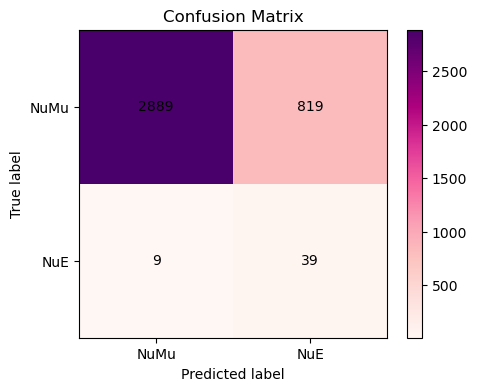

In [80]:
# Make a plot of the confusion matrix to better visualise the performance
cm = confusion_matrix(y_test_f, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="RdPu")
plt.colorbar()
labels = ["NuMu", "NuE"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

# annotate numbers
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

From the confusion matrix and classification report, we can see that the model correctly predicts $\approx 70$% of both $\nu_\mu$ events and $\nu_e$ events. Training with weights can reduce the recall for $\nu_\mu$ events but on the other hand the recall for $\nu_e$ events significantly increases from almost 0% to about 80%. The performance of both classes are now balanced.

## Optional Task 3: Determine lepton energy over neutrino energy (Regression)
We now predict
$$y = \frac{E_l}{E_\mu}$$
This ratio tells us **how much of the neutrino’s energy is transferred to the outgoing lepton**. 
- $y\approx 1$ means most energy goes to the lepton
- $y\approx 0$ means little energy goes to the lepton

In [47]:
# Avoid dividing by zero by masking E>0
mask = nu_energy > 0
X_ratio = X_norm[mask]
nu_energy = nu_energy[mask]
lep_energy = lep_energy[mask]

y_ratio = lep_energy / nu_energy

In [48]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_ratio, y_ratio, test_size=0.2, random_state=42)

In [49]:
ratio_model = keras.Sequential([
    # Use the same convolutional layers for classification
    layers.Input(shape=(100,80,2)),
    layers.Conv2D(16, (3,3), activation='relu',padding="same"),  
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu',padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Random dropouts prevents memorizing specific events
    layers.Dense(64, activation='relu'),
    # Output 1 neuron with sigmoid activation which bounds output from 0 to 1
    layers.Dense(1, activation='sigmoid')])

ratio_model.compile(optimizer='adam', loss=tf.keras.losses.Huber(), metrics=['mae'])
ratio_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 100, 80, 16)    │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 40, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 50, 40, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 25, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,929 (3.87 MB)

 Trainable params: 1,014,929 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
history_r = ratio_model.fit(X_train_r, y_train_r, validation_split=0.2, epochs=20, batch_size=32, callbacks=[early_stop])

Epoch 1/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - loss: 0.0266 - mae: 0.1908 - val_loss: 0.0238 - val_mae: 0.1815
Epoch 2/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - loss: 0.0232 - mae: 0.1767 - val_loss: 0.0227 - val_mae: 0.1771
Epoch 3/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - loss: 0.0221 - mae: 0.1714 - val_loss: 0.0219 - val_mae: 0.1725
Epoch 4/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.0211 - mae: 0.1666 - val_loss: 0.0219 - val_mae: 0.1724
Epoch 5/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - loss: 0.0204 - mae: 0.1634 - val_loss: 0.0218 - val_mae: 0.1709
Epoch 6/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0193 - mae: 0.1585 - val_loss: 0.0216 - val_mae: 0.1691
Epoch 7/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - loss: 0.0183 - mae: 0.1529 - val_loss: 0.0219 - val_mae: 0.1688
Epoch 8/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - loss: 0.0171 - mae: 0.1470 - val_loss: 0.0222 - val_mae: 0.1683
Epoch 9/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 

131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
MAE: 0.16759632527828217


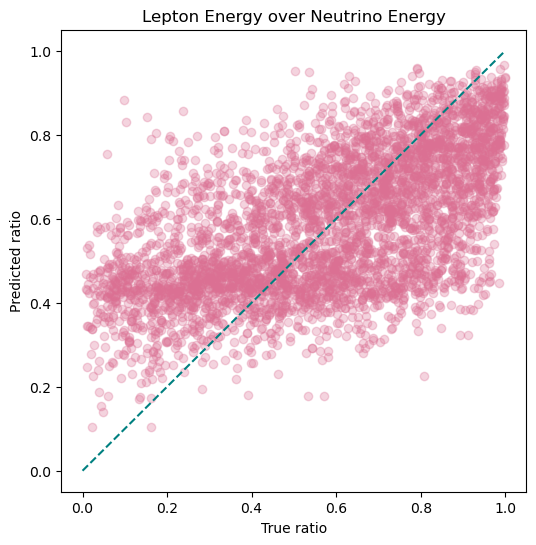

In [51]:
# Evaluate
y_pred_r = ratio_model.predict(X_test_r).flatten()
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
plt.figure(figsize=(6,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color='palevioletred')
plt.plot([0,1],[0,1],"--", color='teal')
plt.xlabel("True ratio")
plt.ylabel("Predicted ratio")
plt.title("Lepton Energy over Neutrino Energy")
plt.show()

The model has a mean absolute error (MAE) of approximately 0.17, which is 17% absolute error, indicating moderate predictive accuracy.

From the scatter plot, we can see that the predicted values follow the overall trend of the true ratio but show significant scatter and a tendency toward regression to the mean. This indicates limited sensitivity to the full picture.

R^2: 0.36551433801651


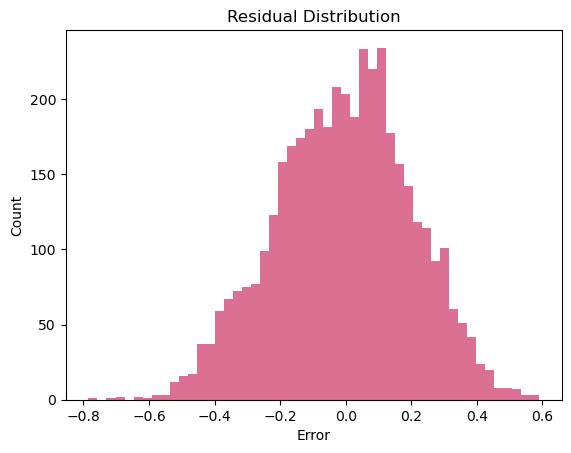

In [52]:
print("R^2:", r2_score(y_test_r, y_pred_r))
residuals = y_test_r - y_pred_r
plt.hist(residuals, bins=50, color='palevioletred')
plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

The relatively low R^2 value (0.366) indicates that while the model captures some correlation between inputs and the target variable, a large fraction of the variance remains unexplained.

The residual distribution is approximately Gaussian (bell shape), suggesting no strong systematic bias. The relatively large spread reflects the inherent uncertainty in predicting the ratio from detector images alone.

## Optional task 4: determine the number of protons or pions
First we need to find the labels for different particles. We will check the 'particles' group in the metadata and see how we can use it to build the model.

In [53]:
with h5py.File(file_path, "r") as f:
    particles = f["neutrino"]["particles"]
    print("Shape:", particles.shape)
    print("Example event:", particles[:5])

Shape: (6916, 1)
Example event: [[ 82]
 [  8]
 [285]
 [  6]
 [ 55]]


The group 'particles' does not give the PDG codes for the particles.

In [54]:
with h5py.File(file_path, "r") as f:
    particles = np.array(f["neutrino"]["particles"]).flatten()
    finalstate = np.array(f["neutrino"]["finalstate"]).flatten()
    finalstateprong = np.array(f["neutrino"]["finalstateprong"]).flatten()

print("Unique particles codes:", np.unique(particles)[:50])
print("Number of unique particles codes:", len(np.unique(particles)))

print("Unique finalstate values:", np.unique(finalstate))
print("Unique finalstateprong values:", np.unique(finalstateprong)[:50])

Unique particles codes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 18 19 20 21 22 23 24 26
 27 28 29 30 32 33 34 35 36 37 38 39 40 41 42 43 45 47 48 49 50 51 52 53
 54 55]
Number of unique particles codes: 190
Unique finalstate values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 20 21 24 25 26 28 29 30
 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 49]
Unique finalstateprong values: [ 0  1  3  5  7  8  9 10 11 13]


I can't find the corresponding labels/ PDG codes for protons and pions... maybe I'll skip this task.

## Optional task 5: Determine the interaction mode
In general:
- **Quasi-elastic (QE)** has simple, few tracks
- **Resonant (RES)** has intermediate tracks
- **Deep Inelastic Scattering (DIS)** has messy events, potentially many tracks and showers

These trends are strongly visible in the images, therefore in this task we again use CNNs which are good at recognising spatial patterns.

In [55]:
def get_interaction_mode_labels(interaction_array):
    """
    Map interaction codes to 3 classes:
        0 = QE
        1 = RES
        2 = DIS
       -1 = ignore all other interactions
    """
    labels = np.full(interaction_array.shape, -1, dtype=np.int32)
    # νμ CC only
    labels[interaction_array == Interaction.kNumuQE.value] = 0
    labels[interaction_array == Interaction.kNumuRes.value] = 1
    labels[interaction_array == Interaction.kNumuDIS.value] = 2
    return labels

We exclude KNumuOther = 3 because these events are all the other $\nu_\mu$ CC interactions that do not fit into QE / RES / DIS. It is not a well-defined class, so the model will likely not be able to learn a clear pattern to classify them.

In [56]:
y_mode = get_interaction_mode_labels(interaction)
numu_mask = (y_mode != -1)  # Exclude non Nu_mu events
X_mode = X_norm[numu_mask]
y_mode = y_mode[numu_mask]

print("X_mode shape:", X_mode.shape)
print("y_mode shape:", y_mode.shape)

# Check class counts
unique, counts = np.unique(y_mode, return_counts=True)
print("Class counts:", dict(zip(unique, counts)))

X_mode shape: (17968, 100, 80, 2)
y_mode shape: (17968,)
Class counts: {np.int32(0): np.int64(2625), np.int32(1): np.int64(3989), np.int32(2): np.int64(11354)}


The class counts show 2625 QE events, 3989 RES events and 11354 DIS events. There is a huge imbalance between the interaction modes, so we need to introduce weights to prevent the model from prredicting DIS only.

In [57]:
# Train test split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mode, y_mode, test_size=0.2, random_state=42, stratify=y_mode)

X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(
    X_train_m, y_train_m, test_size=0.2, random_state=42, stratify=y_train_m)

In [58]:
# Compute class weight
classes = np.unique(y_train_m)
class_weights_array = compute_class_weight(class_weight="balanced",classes=classes,y=y_train_m)

class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Class weights:", class_weights)

Class weights: {0: 2.281547619047619, 1: 1.5013709361535448, 2: 0.5275254610514726}


(Using these computed weights resulted in bad performance over all interaction modes, likely because the model overcorrected its predicting behaviour.)

In [72]:
# Empirically adjusted milder weights
class_weights_mild = {0: 2.1, 1: 1.4, 2: 0.65}

In [60]:
# Build a CNN model
model_mode = keras.Sequential([
    layers.Input(shape=(100,80,2)),
    # Use the same convolutional layers for classification
    layers.Conv2D(8,3,activation="relu",padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(16,3,activation="relu",padding="same"),
    layers.MaxPooling2D(2),
    layers.Conv2D(32,3,activation="relu",padding="same"),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(32,activation="relu"),
    layers.Dropout(0.5),   # bigger dropout to prevent overfitting 
    layers.Dense(3, activation="softmax")   # Outputs QE / RES / DIS
])

model_mode.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_mode.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 100, 80, 8)     │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 50, 40, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 40, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       122,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,971 (503.79 KB)

 Trainable params: 128,971 (503.79 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Train
history_mode = model_mode.fit(X_train_m, y_train_m, validation_data=(X_val_m, y_val_m),
    epochs=20, batch_size=32, callbacks=[early_stop], class_weight=class_weights_mild)

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4800 - loss: 1.0515 - val_accuracy: 0.5610 - val_loss: 0.9088
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4860 - loss: 1.0468 - val_accuracy: 0.5461 - val_loss: 0.9102
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.4949 - loss: 1.0350 - val_accuracy: 0.5489 - val_loss: 0.9080
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5082 - loss: 1.0300 - val_accuracy: 0.5485 - val_loss: 0.9145
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5257 - loss: 1.0176 - val_accuracy: 0.5718 - val_loss: 0.8978


In [74]:
# Analyse
y_pred_prob = model_mode.predict(X_test_m)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test_m, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test_m, y_pred, target_names=["QE","RES","DIS"]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Confusion Matrix:
[[ 108  143  274]
 [ 109  266  423]
 [ 315  297 1659]]

Classification Report:
              precision    recall  f1-score   support

          QE       0.20      0.21      0.20       525
         RES       0.38      0.33      0.35       798
         DIS       0.70      0.73      0.72      2271

    accuracy                           0.57      3594
   macro avg       0.43      0.42      0.43      3594
weighted avg       0.56      0.57      0.56      3594



We can see that even with tuned weights, the classifier only somewhat learned QE events and still struggles to identify RES events. 

Without weights, the model would predict almost all the events to be DIS events. This increases the overall accuracy, but is essentially a useless model as it learns to give the same prediction all the time. Introducing class weights forces the model to make different guesses, but fails to improve the performance further.

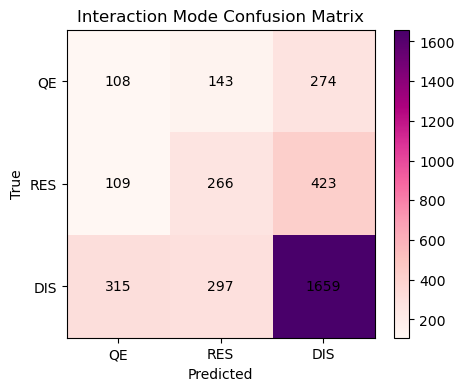

In [75]:
# Plot confusion matrix for better visualisation
plt.figure(figsize=(5,4))
plt.imshow(cm,cmap="RdPu")
plt.colorbar()
labels = ["QE","RES","DIS"]
plt.xticks([0,1,2], labels)
plt.yticks([0,1,2], labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Interaction Mode Confusion Matrix")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

The three-class classifier has unsatisfactory performance even after tuning hyperparameters and class weights. This is primarily due to the intrinsic similarity between QE and RES interactions, which produce similar low-multiplicity topologies in the detector. 

In contrast, DIS events exhibit more complex structures and are more easily identifiable. The large proportion of DIS events also impacts the classifier's predictions. As a result, the model achieves good performance for DIS but struggles to distinguish between QE and RES. 

Instead of building a 3-class classifier, let's **try building a binary classifier by merging QE events and RES events** and see how it performs.

In [64]:
binary_mask = np.isin(interaction, [0,1,2])   # Filter out νμ CC QE/RES/DIS first
X_mode_bin = X_norm[binary_mask]
y_mode_bin = (interaction[binary_mask]==2).astype(np.float32)  # Give False to 0,1, True to 2 

In [65]:
# Train test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_mode_bin, y_mode_bin,
                                                            test_size=0.2, random_state=42, stratify=y_mode_bin)

X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(X_train_b, y_train_b, 
                                                          test_size=0.2, random_state=42, stratify=y_train_b)

In [66]:
# Introduce mild class weights
class_weights = {0: 1.4,   # QE+RES
                 1: 1.1    # DIS
                }
# Use the same model for binary classification in task 1:
history_bin = model.fit(X_train_b, y_train_b, validation_data=(X_val_b, y_val_b),
                        epochs=20, batch_size=32, class_weight=class_weights, callbacks=[early_stop])

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.5947 - loss: 0.8012 - val_accuracy: 0.6090 - val_loss: 0.6217
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.6195 - loss: 0.7679 - val_accuracy: 0.6271 - val_loss: 0.6133
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.6288 - loss: 0.7599 - val_accuracy: 0.6243 - val_loss: 0.6138
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.6346 - loss: 0.7543 - val_accuracy: 0.6334 - val_loss: 0.6081
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6424 - loss: 0.7454 - val_accuracy: 0.6369 - val_loss: 0.6059


In [67]:
y_pred_prob = model.predict(X_test_b)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test_b, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred, target_names=["QE+RES", "DIS"]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Confusion Matrix:
[[ 774  549]
 [ 814 1457]]

Classification Report:
              precision    recall  f1-score   support

      QE+RES       0.49      0.59      0.53      1323
         DIS       0.73      0.64      0.68      2271

    accuracy                           0.62      3594
   macro avg       0.61      0.61      0.61      3594
weighted avg       0.64      0.62      0.63      3594



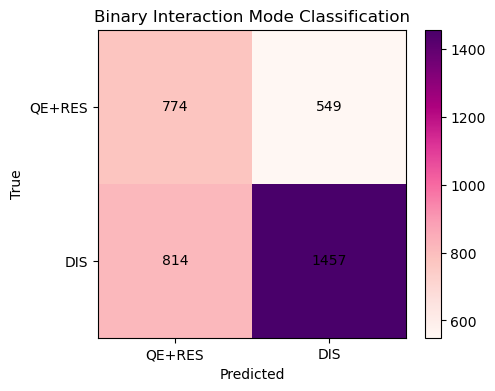

In [68]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="RdPu")
plt.colorbar()
labels = ["QE+RES", "DIS"]
plt.xticks([0,1], labels)
plt.yticks([0,1], labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Binary Interaction Mode Classification")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

We can see that there are no class collapse anymore. With adjusted weights the binary classifier achieves a balanced performance between QE+RES and DIS events and is no longer strongly biased towards one class.

This reflects the underlying physics: DIS events produce more complex tracks, therefore are more easily identified, while QE and RES events remain more challenging due to their similar structures.